# Task 5 – Uncertainty Evaluation

A ResNet18 model with dropout is evaluated using Monte Carlo (MC) Dropout. The variation across repeated predictions is used to estimate uncertainty.


In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from scipy.stats import mannwhitneyu
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms

## Load Data

In [46]:
# Paths to data
train_images_folder = 'Data/Training/Training_Images'
train_csv           = 'Data/Training/Training_LabelsDemographic.csv'
test_images_folder  = 'Data/Testing/Testing_Images'
test_csv            = 'Data/Testing/Testing_LabelDemographic.csv'

# Load labels
train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

print('Training samples:', len(train_df))
print('Test samples:    ', len(test_df))
train_df.head()

Training samples: 1143
Test samples:     248


,image,myopic_maculopathy_grade,age,sex,height,weight,data_center
0,mmac_task_1_train_0001.png,0,51,male,183.5,78.9,1
1,mmac_task_1_train_0002.png,0,51,male,183.5,78.9,1
2,mmac_task_1_train_0003.png,0,50,male,184.5,81.7,1
3,mmac_task_1_train_0004.png,0,50,male,184.5,81.7,1
4,mmac_task_1_train_0005.png,0,49,male,184.5,82.2,1


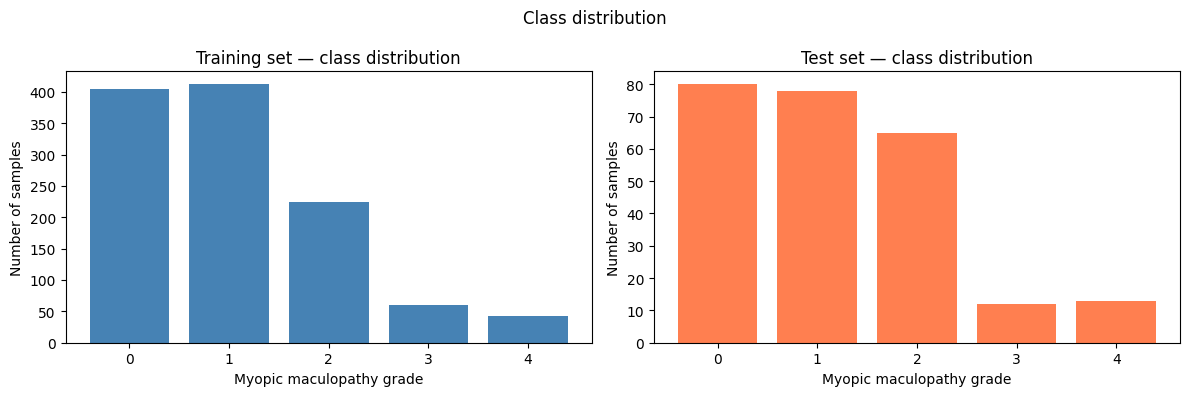

In [47]:
# Class distribution of dataset to identify imbalance
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
test_counts = test_df["myopic_maculopathy_grade"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training set
axes[0].bar(class_counts.index, class_counts.values, color="steelblue")
axes[0].set_xlabel("Myopic maculopathy grade")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Training set — class distribution")
axes[0].set_xticks(class_counts.index)

# Test set
axes[1].bar(test_counts.index, test_counts.values, color="coral")
axes[1].set_xlabel("Myopic maculopathy grade")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Test set — class distribution")
axes[1].set_xticks(test_counts.index)

plt.suptitle("Class distribution", fontsize=12)
plt.tight_layout()
plt.show()

In [48]:
# Demographic statistics to identify potential sources of bias in the dataset.
age_summary = pd.DataFrame({"Metric": ["Age (mean)", "Age (std)", "Age (min)", "Age (max)"],
    "Value": [train_df["age"].mean(), train_df["age"].std(), train_df["age"].min(), train_df["age"].max() ]})

display(age_summary)

# Sex distribution table
sex_summary = train_df["sex"].value_counts().rename_axis("Sex").reset_index(name="Count")
display(sex_summary)

# Data centre distribution table
centre_summary = train_df["data_center"].value_counts().rename_axis("Data centre").reset_index(name="Count")
display(centre_summary)

,Metric,Value
0,Age (mean),53.846019
1,Age (std),10.498641
2,Age (min),29.000000
3,Age (max),93.000000


,Sex,Count
0,male,697
1,female,293


,Data centre,Count
0,1,990
1,2,153


## Data transformation

In [49]:
# Image preprocessing (RGB)
transform = transforms.Compose([transforms.Resize((224, 224)),transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [50]:
# Custom dataset to load images and corresponding labels
class MMACDataset(Dataset):
    """Custom dataset for MMAC retinal images."""
    def __init__(self, df, images_folder, transform=None):
        self.df            = df.reset_index(drop=True)
        self.images_folder = images_folder
        self.transform     = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row        = self.df.iloc[idx]
        image_name = row['image']
        label      = int(row['myopic_maculopathy_grade'])
        image_path = os.path.join(self.images_folder, image_name)
        image      = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return {'image': image,
                'label': torch.tensor(label, dtype=torch.long),
                'image_name': image_name}

## Train / validation

The training data is split into 80% training and 20% validation, making sure all classes are represented in both sets. The validation set is used later for calibration.


In [51]:
# Train/validation split
train_idx, val_idx = train_test_split( np.arange(len(train_df)),
                     test_size=0.2, stratify=train_df['myopic_maculopathy_grade'].values, random_state=42)

full_train_dataset = MMACDataset(train_df, train_images_folder, transform=transform)
test_dataset = MMACDataset(test_df, test_images_folder, transform=transform)

train_subset = Subset(full_train_dataset, train_idx)
val_subset   = Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train: {len(train_subset)} | Val: {len(val_subset)} | Test: {len(test_dataset)}")


Train: 914 | Val: 229 | Test: 248


## ResNet18 with dropout

A pre-trained ResNet18 model is used for classification with a dropout layer added before the final layer. The model is run multiple times with dropout active during inference to estimate uncertainty.


In [52]:
class ResNet18Dropout(nn.Module):
    """ ResNet18 with dropout before the final classification layer."""
    def __init__(self, num_classes=5, dropout_p=0.3):
        super().__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(nn.Dropout(p=dropout_p), nn.Linear(in_features, num_classes))

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 6. Training

In [53]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        images = batch['image'].to(device)
        labels = batch['label'].to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    """Evaluate model with dropout disabled."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device)
            labels = batch["label"].to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [54]:
## Model training loop
model     = ResNet18Dropout(num_classes=5, dropout_p=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 12
train_losses, train_accs = [], []
val_losses,   val_accs   = [], []

MODEL_PATH = 'task5_resnet18_dropout.pth'

# Load saved weights if available, otherwise train from scratch
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print('Loaded saved model from', MODEL_PATH)
else:
    print('Training model...')
    for epoch in tqdm(range(num_epochs), desc='Training'):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate(model, val_loader, criterion, device)
        train_losses.append(t_loss);  train_accs.append(t_acc)
        val_losses.append(v_loss);    val_accs.append(v_acc)
        print(f'Epoch {epoch+1}/{num_epochs} — '
              f'Train loss: {t_loss:.4f}, acc: {t_acc:.4f} | '
              f'Val loss: {v_loss:.4f}, acc: {v_acc:.4f}')
    torch.save(model.state_dict(), MODEL_PATH)
    print('Model saved to', MODEL_PATH)

Loaded saved model from task5_resnet18_dropout.pth


In [55]:
# Plot training and validation curves (only if we just trained)
if train_losses:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(train_losses, label='Train'); axes[0].plot(val_losses, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over epochs'); axes[0].legend()
    axes[1].plot(train_accs, label='Train'); axes[1].plot(val_accs, label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy over epochs'); axes[1].legend()
    plt.tight_layout(); plt.show()


## MC Dropout inference

The model is run multiple times with dropout active during inference. The variation in predictions is used to estimate uncertainty. Entropy and variance are computed as measures of uncertainty.


In [56]:
def mc_dropout_inference(model, images, T=30):
    """Run multiple forward passes with dropout active to estimate uncertainty.
    Returns mean prediction, variance, and entropy-based uncertainty measures."""
    model.train()  # keep dropout active during inference
    preds = []

    with torch.no_grad():
        for _ in range(T):
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds.append(probs)

    preds = torch.stack(preds)          
    mean_pred = preds.mean(dim=0)       

    # Variance across passes
    variance = preds.var(dim=0).mean(dim=1)
    # Total uncertainty (entropy)
    total_entropy = -(mean_pred * torch.log(mean_pred + 1e-8)).sum(dim=1)
    per_pass_entropy = -(preds * torch.log(preds + 1e-8)).sum(dim=2)
  
    return mean_pred, variance, total_entropy


## Evaluation on the test set

In [57]:
# For each image, the predicted label, confidence, uncertainty measures, and correctness are stored.
all_true, all_pred, all_conf = [], [], []
all_variance = []
all_entropy = []
all_correct = []
all_names = []

for batch in tqdm(test_loader, desc="MC Dropout evaluation (T=30)"):
    images = batch["image"].to(device)
    labels = batch["label"].to(device)
    image_names = batch["image_name"]

    mean_pred, variance, entropy = mc_dropout_inference(model, images, T=30)

    preds = torch.argmax(mean_pred, dim=1)
    conf = mean_pred.max(dim=1).values

    # Collect raw logits with dropout disabled
    model.eval()
    with torch.no_grad():
        raw_logits = model(images)
    model.train()

    all_true.extend(labels.cpu().numpy())
    all_pred.extend(preds.cpu().numpy())
    all_conf.extend(conf.cpu().numpy())
    all_variance.extend(variance.cpu().numpy())
    all_entropy.extend(entropy.cpu().numpy())
    all_correct.extend((preds == labels).cpu().numpy())
    all_names.extend(image_names)

results_df = pd.DataFrame({
    "image_name": all_names,
    "true_label": all_true,
    "pred_label": all_pred,
    "confidence": all_conf,
    "variance": all_variance,
    "entropy": all_entropy,
    "correct": all_correct,})

accuracy = results_df["correct"].mean()
print(f"Test accuracy: {accuracy:.4f} ({results_df['correct'].sum()}/{len(results_df)})")

results_df.head()


MC Dropout evaluation (T=30): 100%|██████████| 16/16 [03:04<00:00, 11.52s/it]

Test accuracy: 0.5685 (141/248)


,image_name,true_label,pred_label,confidence,variance,entropy,correct
0,mmac_task_1_val_0001.png,3,0,0.806402,0.001711,0.674786,False
1,mmac_task_1_val_0002.png,3,1,0.990646,0.000011,0.053479,False
2,mmac_task_1_val_0003.png,2,0,0.539971,0.004749,1.207344,False
3,mmac_task_1_val_0004.png,2,2,0.785831,0.002220,0.715828,True
4,mmac_task_1_val_0005.png,2,0,0.257978,0.003272,1.564180,False


In [58]:
# Mean uncertainty for correct vs incorrect predictions
correct_df = results_df[results_df["correct"]]
incorrect_df = results_df[~results_df["correct"]]

summary = pd.DataFrame({"Metric": ["Total entropy", "Variance", "Confidence"],
    "Correct": [
        correct_df["entropy"].mean(),
        correct_df["variance"].mean(),
        correct_df["confidence"].mean()],
    "Incorrect": [
        incorrect_df["entropy"].mean(),
        incorrect_df["variance"].mean(),
        incorrect_df["confidence"].mean() ], }).round(6)

display(summary)

,Metric,Correct,Incorrect
0,Total entropy,0.244645,0.427949
1,Variance,0.000812,0.001640
2,Confidence,0.920864,0.843631


## Confusion matrix
The confusion matrix shows how predictions are distributed across classes.

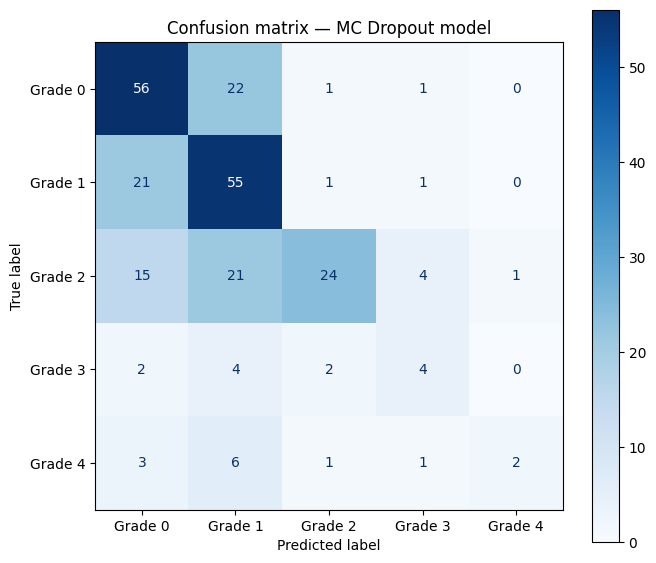

In [59]:
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(results_df["true_label"], results_df["pred_label"])
disp = ConfusionMatrixDisplay(cm, display_labels=[f"Grade {i}" for i in range(5)])
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title("Confusion matrix — MC Dropout model")

plt.tight_layout()
plt.show()

## Uncertainty distributions 
Uncertainty is compared between correct and incorrect predictions.

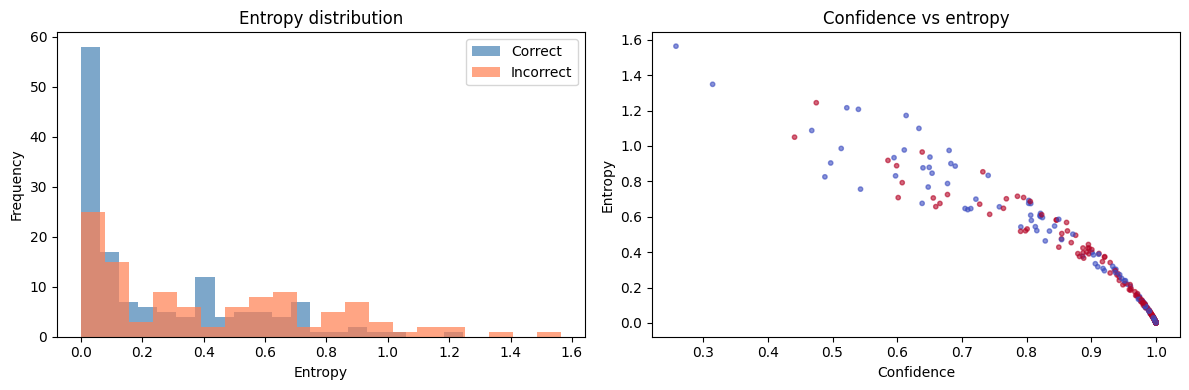

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Entropy histogram
axes[0].hist(correct_df["entropy"], bins=20, alpha=0.7, label="Correct", color="steelblue")
axes[0].hist(incorrect_df["entropy"], bins=20, alpha=0.7, label="Incorrect", color="coral")
axes[0].set_xlabel("Entropy")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Entropy distribution")
axes[0].legend()

# Confidence vs entropy
axes[1].scatter(results_df["confidence"], results_df["entropy"], c=results_df["correct"].astype(int), cmap="coolwarm", alpha=0.6, s=10)
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Entropy")
axes[1].set_title("Confidence vs entropy")

plt.tight_layout()
plt.show()

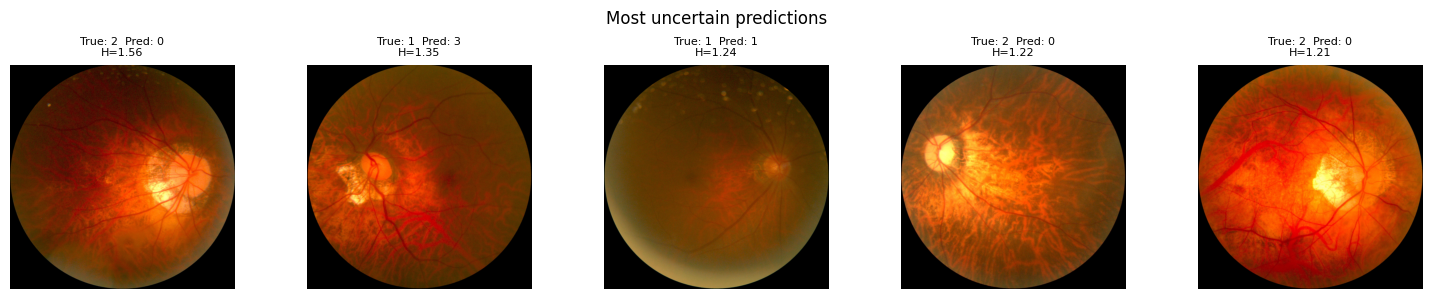

In [61]:
# Display the 5 most uncertain test images
top_uncertain = results_df.sort_values("entropy", ascending=False).head(5)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, (_, row) in zip(axes, top_uncertain.iterrows()):
    img_path = os.path.join(test_images_folder, row["image_name"])
    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    ax.set_title(f"True: {int(row['true_label'])}  Pred: {int(row['pred_label'])}\n"
        f"H={row['entropy']:.2f}", fontsize=8 )
    ax.axis("off")

plt.suptitle("Most uncertain predictions", fontsize=12)
plt.tight_layout()
plt.show()

In [62]:
# Save full uncertainty results for use in comparative evaluation
results_df.to_csv("Task5_uncertainty_results.csv", index=False)
print("Results saved to Task5_uncertainty_results.csv")

Results saved to Task5_uncertainty_results.csv
